In [100]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from quantum_cva.mc_benchmark.benchmark_utils import (
    simulate_S,
    price_grid_from_samples,
    discrete_probs_from_samples,
)

from warnings import filterwarnings
from quantum_cva.state_prep.qcbm.p_target import build_joint_target_from_P_bin
from quantum_cva.state_prep.qcbm.qcbm_circuit import QcbmCircuit
from quantum_cva.state_prep.qcbm.train_utils import (minimize_with_cost_history, save_qcbm_distributions, 
                                                     plot_qcbm_training_diagnostics, plot_joint_and_marginals)
from qiskit_algorithms.optimizers import SPSA
from scipy.optimize import minimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
# Root to data folder 
from pathlib import Path
import quantum_cva
import json

REPO_ROOT = Path(quantum_cva.__file__).resolve().parents[2]
OUT_DIR = REPO_ROOT / "data" / "qcbm"
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Loading target probability distribution $p_{tg}(x)$ (clasically computed)

In [19]:
# Discretization parameters
n = 2
m = 2
N = 2**n  # number of price bins
M = 2**m  # number of time steps

In [20]:
# ============================================================
# 0) Reproducibility
# ============================================================
np.random.seed(123)
 
# ============================================================
# 1) Simulate S(t) paths
# ============================================================

# Simulation parameters
S0 = 5.0
K = 5.5
sigma = 0.25
r = 0.02

# Fine time grid
T = 184/360
N_paths = 100_000
M_fine = 8 # diary steps
t = np.linspace(0.0, T, M_fine+1)

# Simulate paths
n_paths = 10000
Z = np.random.standard_normal(size=(n_paths, M_fine))

S_by_time = simulate_S(S0=S0, mu=r, sigma=sigma, t=t, Z=Z)

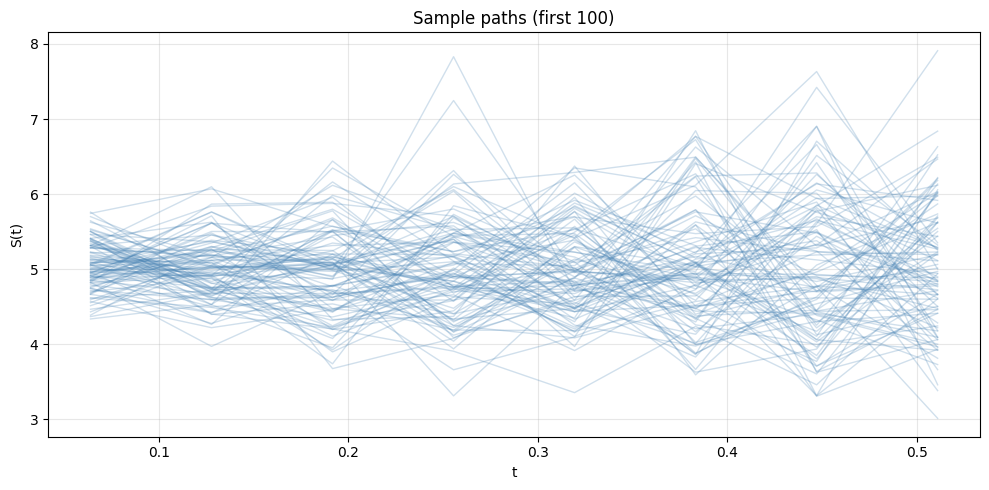

In [21]:
# Plot some sample paths and histogram at T
n_plot = 100
S_plot = np.vstack([s[:n_plot] for s in S_by_time])

plt.figure(figsize=(10, 5))
for k in range(n_plot):
    plt.plot(t[1:], S_plot[:, k], color="steelblue", alpha=0.25, linewidth=1.0)
plt.title("Sample paths (first 100)")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# ============================================================
# 2) Discretize prices: choose n so that N=2^n bins (power of two)
# ============================================================
n_sigma = 3.0

edges, grid_info = price_grid_from_samples(S_by_time, n=n, n_sigma=n_sigma)
print("Grid info:", grid_info)
print("edges length:", len(edges), "=> N bins:", len(edges) - 1)
assert (len(edges) - 1) == N

Grid info: [2.99976573 4.36808721 5.73640869 7.10473017]
edges length: 5 => N bins: 4


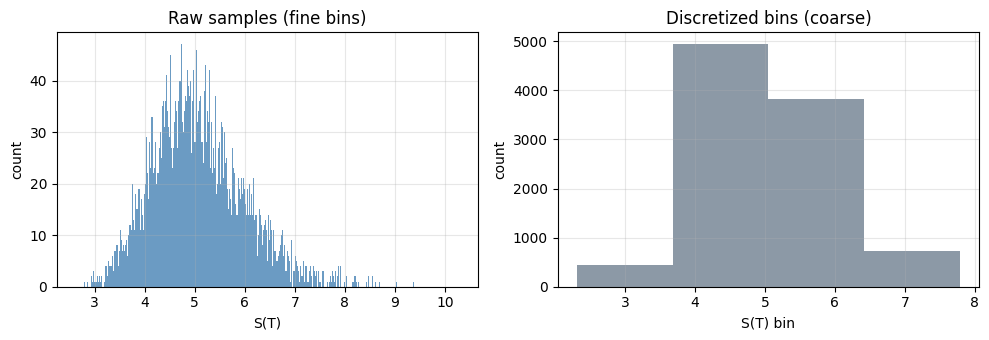

In [23]:
# ============================================================
# 2b) Histogram: raw vs discretized prices (loss of resolution)
# ============================================================
t_idx = -1  # use final exposure date
samples = S_by_time[t_idx]

# Raw histogram (fine bins)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(samples, bins=1000, color="steelblue", alpha=0.8)
axes[0].set_title("Raw samples (fine bins)")
axes[0].set_xlabel("S(T)")
axes[0].set_ylabel("count")
axes[0].grid(True, alpha=0.3)

# Discretized histogram using the grid edges
counts, _ = np.histogram(samples, bins=edges)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
bin_widths = edges[1:] - edges[:-1]
axes[1].bar(bin_centers, counts, width=bin_widths, color="slategray", alpha=0.8, align="center")
axes[1].set_title("Discretized bins (coarse)")
axes[1].set_xlabel("S(T) bin")
axes[1].set_ylabel("count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 3) Build conditional distributions P_bin[i,:] = P(s_bin | t_i)
# ============================================================
P_bin = np.zeros((M, N), dtype=float) #! here we work with M time steps (coarse time grid, not the one used for sim)
for i in range(M):
    P_bin[i, :] = discrete_probs_from_samples(S_by_time[i], edges)

assert P_bin.shape == (M, N)
assert np.all(P_bin >= -1e-15)
assert np.allclose(P_bin.sum(axis=1), 1.0, atol=1e-10)
print("P_bin OK. shape:", P_bin.shape)

P_bin OK. shape: (4, 4)


In [25]:
# ============================================================
# 4) Build joint target for QCBM 
#    p_tg(i,j) = P(t_i) P(s_j|t_i), with uniform P(t_i)=1/M by default
# ============================================================
tgt = build_joint_target_from_P_bin(P_bin, order="time_major") 

print("\n--- Joint target summary ---")
print(f"M={tgt.M} (m={tgt.m} qubits), N={tgt.N} (n={tgt.n} qubits)")
print("len(p_tg) =", tgt.p_tg.size, "(expected M*N =", tgt.M * tgt.N, ")")
print("sum(p_tg) =", tgt.p_tg.sum())

assert tgt.M == M
assert tgt.N == N
assert tgt.p_tg.ndim == 1
assert tgt.p_tg.size == M * N
assert abs(tgt.p_tg.sum() - 1.0) < 1e-12


--- Joint target summary ---
M=4 (m=2 qubits), N=4 (n=2 qubits)
len(p_tg) = 16 (expected M*N = 16 )
sum(p_tg) = 1.0


Joint target distribution:
$$
p_{tg}(x),
$$
a flatten vector with $2^{n + m}$ elements. So the register $x$ is written in the computational basis of $n + m$ qubits.

In [26]:
# ============================================================
# Print all computational basis states directly from p_tg
# ============================================================
# Sanity check: check dimensions of tgt are correct
ptg = tgt.p_tg
m = tgt.m      # time qubits
n = tgt.n      # price qubits
M = tgt.M
N = tgt.N

def to_bits(x, L):
    return format(x, f"0{L}b")

print("Probability distribution over computational basis states (quantum - friendly):")

for x, prob in enumerate(ptg):
    # Binary representation of the full register
    bits = to_bits(x, m + n)

    # Decode indices according to time_major convention
    i = x // N          # time index
    j = x % N           # price-bin index

    bits_time  = bits[:m]
    bits_price = bits[m:]

    print(
        f"|{bits}>  "
        f"(t_{i+1}, s_{j})  "
        f"P = {prob:.6e}"
    )


Probability distribution over computational basis states (quantum - friendly):
|0000>  (t_1, s_0)  P = 0.000000e+00
|0001>  (t_1, s_1)  P = 1.410750e-01
|0010>  (t_1, s_2)  P = 1.089250e-01
|0011>  (t_1, s_3)  P = 0.000000e+00
|0100>  (t_2, s_0)  P = 5.000000e-05
|0101>  (t_2, s_1)  P = 1.380000e-01
|0110>  (t_2, s_2)  P = 1.114500e-01
|0111>  (t_2, s_3)  P = 5.000000e-04
|1000>  (t_3, s_0)  P = 6.000600e-04
|1001>  (t_3, s_1)  P = 1.360636e-01
|1010>  (t_3, s_2)  P = 1.106861e-01
|1011>  (t_3, s_3)  P = 2.650265e-03
|1100>  (t_4, s_0)  P = 1.775178e-03
|1101>  (t_4, s_1)  P = 1.317882e-01
|1110>  (t_4, s_2)  P = 1.110111e-01
|1111>  (t_4, s_3)  P = 5.425543e-03


---

## QCBM ansatz definition & training

In [30]:
# Rename discretization variables to enhance quantum readability
num_qubits_price = n
num_qubits_time = m
num_qubits = num_qubits_price + num_qubits_time

In [44]:
# Ansatz definition
EPS_COST = 1e-12

qcbm = QcbmCircuit(n_qubits=num_qubits, name="G_p")
qc, theta = qcbm.qc, qcbm.theta

print(qc.draw(output="text", fold=120))

     ┌──────────────┐┌──────────────┐┌────────────────┐┌────────────────┐┌─────────────────┐                   »
q_0: ┤ Rx(theta[0]) ├┤ Rz(theta[1]) ├┤0               ├┤0               ├┤0                ├───────────────────»
     ├──────────────┤├──────────────┤│  Rxx(theta[8]) ││                ││                 │┌─────────────────┐»
q_1: ┤ Rx(theta[2]) ├┤ Rz(theta[3]) ├┤1               ├┤  Rxx(theta[9]) ├┤                 ├┤0                ├»
     ├──────────────┤├──────────────┤└────────────────┘│                ││  Rxx(theta[10]) ││  Rxx(theta[11]) │»
q_2: ┤ Rx(theta[4]) ├┤ Rz(theta[5]) ├──────────────────┤1               ├┤                 ├┤1                ├»
     ├──────────────┤├──────────────┤                  └────────────────┘│                 │└─────────────────┘»
q_3: ┤ Rx(theta[6]) ├┤ Rz(theta[7]) ├────────────────────────────────────┤1                ├───────────────────»
     └──────────────┘└──────────────┘                                    └─────────────────┘    

### Ideal Probability Evaluation vs. Shot-Based Estimation

In variational quantum algorithms such as Quantum Circuit Born Machines (QCBMs), the model distribution is defined by the Born probabilities of a parameterized quantum circuit. There are two conceptually distinct ways of accessing these probabilities: the *ideal (statevector)* evaluation and the *shot-based* estimation. Although both originate from the same underlying quantum state, they differ fundamentally in how probabilities are obtained and in the presence of statistical noise.


<br>


In the **ideal *(statevector)* setting**, the parameterized circuit $U(\theta)$ is applied to the computational basis state $|0\cdots 0\rangle$, and the full quantum state is computed exactly:
$$
|\psi(\theta)\rangle = U(\theta)\,|0\cdots 0\rangle
= \sum_{x \in \{0,1\}^n} a_x(\theta)\,|x\rangle .
$$

All complex amplitudes $a_x(\theta)$ are explicitly available. The model probabilities are then obtained deterministically as

$$
\boxed{
p_\theta(x) = |a_x(\theta)|^2 \quad \text{for all } x .
}
$$


This procedure involves no sampling and no measurement. The resulting probability vector is exact, the loss function is deterministic, and repeated evaluations at the same parameters $\theta$ always return the same value. This regime is accessible only in classical simulation and serves as an idealized reference for analysis and debugging.


<br>

In contrast, while working in a ***shot-based* setting**, the circuit is followed by measurements in the computational basis. Each execution (shot) produces a single bitstring outcome
$$
X \in \{0,1\}^n,
$$
distributed according to the Born rule:
$$
\mathbb{P}(X = x) = |a_x(\theta)|^2 .
$$

Repeating the experiment $N_{\text{shots}}$ times yields independent and identically distributed samples $X_1, \dots, X_{N_{\text{shots}}}$. The probabilities are then estimated empirically via relative frequencies,

$$
\boxed{
\hat p_\theta(x) = \frac{1}{N_{\text{shots}}}
\sum_{k=1}^{N_{\text{shots}}} \mathbf{1}_{\{X_k = x\}} .
}
$$

The resulting estimator is unbiased,
$$
\mathbb{E}[\hat p_\theta(x)] = p_\theta(x),
$$
but exhibits statistical fluctuations with variance
$$
\mathrm{Var}[\hat p_\theta(x)] =
\frac{p_\theta(x)\bigl(1 - p_\theta(x)\bigr)}{N_{\text{shots}}}.
$$

Consequently, any cost function built from $\hat p_\theta$ is inherently noisy, and its evaluation varies from call to call even at fixed parameters.

In the limit $N_{\text{shots}} \to \infty$, the shot-based estimator converges to the ideal probabilities, but for any finite number of shots, statistical noise is unavoidable. This difference has direct consequences for optimization, as noise-free objective functions are fundamentally easier to minimize than their stochastic counterparts.

#### 1. Estimation under the ideal (*statevector*) setting.

Hyperparameters of the training

In [82]:
# ---- fixed hyperparams / reproducibility ----
SEED = 123
N_ITERS = 7000
METHOD = "COBYLA"

rng = np.random.default_rng(SEED)
x0 = rng.standard_normal(len(theta)).astype(float)

Optimization (Training) of the quantum circuit

In [84]:
# Define cost function
cost = qcbm.cost_fn(ptg, eps=EPS_COST)

# Run the optimization
res, cost_history = minimize_with_cost_history(
    cost,
    x0=x0,
    minimize_fn=minimize,
    method=METHOD,
    options={"maxiter": int(N_ITERS), 
             "rhobeg": RHOBEG,
             "disp": True},
)

theta_star = np.asarray(res.x, dtype=float)

# ------ Probabilities: p0 -> before training, p_star -> after training ------ 
p0 = qcbm.probabilities(x0)
p_star = qcbm.probabilities(theta_star)
# ----------------------------------------------------------------------------

print("success:", res.success)
print("message:", res.message)
print("nfev:", getattr(res, "nfev", None), "nit:", getattr(res, "nit", None))
print("final cost:", float(res.fun))

success: False
message: Maximum number of function evaluations has been exceeded.
nfev: 7000 nit: None
final cost: 2.1259356196610613


In [ ]:
ms = qcbm.metrics(ptg, p_star)

print("\n=== 'FIT' METRIC + OTHERS ===")
print("KL(ptg || p*)  =", float(ms["kl"]))
print("L1             =", float(ms["l1"]))
print("TV = 0.5*L1    =", float(ms["tv"]))
print("Linf           =", float(ms["linf"]))

print("\n=== 4x4 MATRICES (rows=t_i, cols=s_j) ===")
print("ptg:\n")
print(ptg)
print("\np_star:\n")
print(p_star)


=== 'FIT' METRIC + OTHERS ===
KL(ptg || p*)  = 0.00016331837859308345
L1             = 0.013351526556117764
TV = 0.5*L1    = 0.006675763278058882
Linf           = 0.0028819213096265006

=== 4x4 MATRICES (rows=t_i, cols=s_j) ===
ptg:

[0.00000000e+00 1.41075000e-01 1.08925000e-01 0.00000000e+00
 5.00000000e-05 1.38000000e-01 1.11450000e-01 5.00000000e-04
 6.00060006e-04 1.36063606e-01 1.10686069e-01 2.65026503e-03
 1.77517752e-03 1.31788179e-01 1.11011101e-01 5.42554255e-03]

p_star:

[1.16662830e-05 1.42902110e-01 1.08046667e-01 2.61208078e-06
 9.77297117e-05 1.35118079e-01 1.10551347e-01 4.65534753e-04
 5.54222255e-04 1.34568687e-01 1.11117973e-01 2.97481581e-03
 1.88739140e-03 1.34282209e-01 1.12435047e-01 4.98390855e-03]


In [86]:
npz_path, json_path = save_qcbm_distributions(
    qcbm=qcbm,
    p_trained=p_star,
    p_target=ptg,
    filename_stem="qcbm_output_distribution",
    metadata={"optimizer": METHOD, "seed": SEED, "n_iters": N_ITERS},
)
print(npz_path)
print(json_path)


C:\Users\guilb\Desktop\Quantum-CVA\data\qcbm\qcbm_output_distribution.npz
C:\Users\guilb\Desktop\Quantum-CVA\data\qcbm\qcbm_output_distribution.json


In [88]:
# --- Alcázar-style rescaling: ideal value ~ 0 ---
C_star = -np.sum(ptg * np.log(np.maximum(ptg, EPS_COST)))
rescaled = cost_history - C_star
rescaled_plot = np.maximum(rescaled, 1e-12)          # for semilogy
best_so_far = np.minimum.accumulate(rescaled_plot)

tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

<string>:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


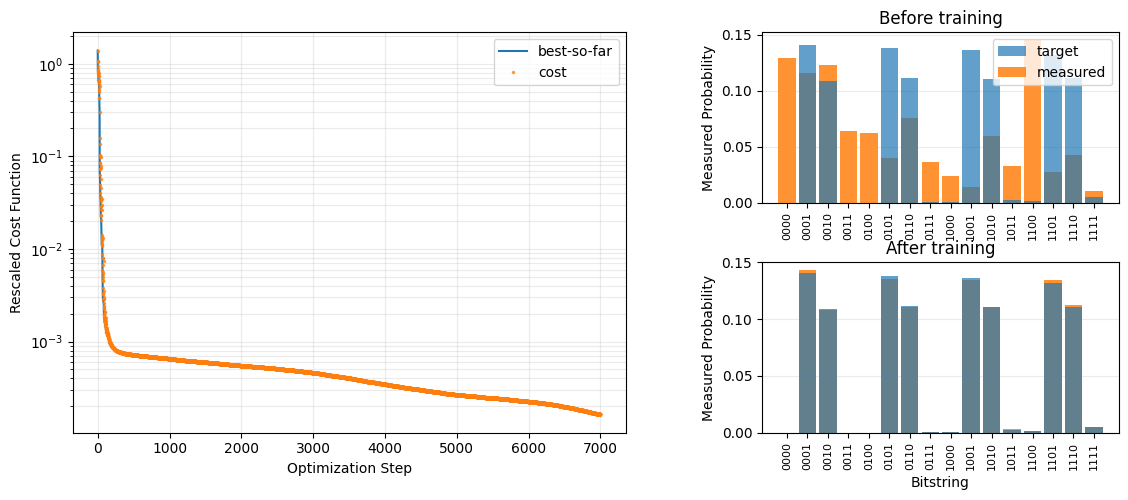

In [ ]:
plot_qcbm_training_diagnostics(
    ptg=ptg,
    p0=p0,
    p_star=p_star,
    cost_history=rescaled_plot,
    best_so_far=best_so_far,
    best_idx=best_idx,
    m=m,
    n=n,
)

Some graphics for enhanced visualization

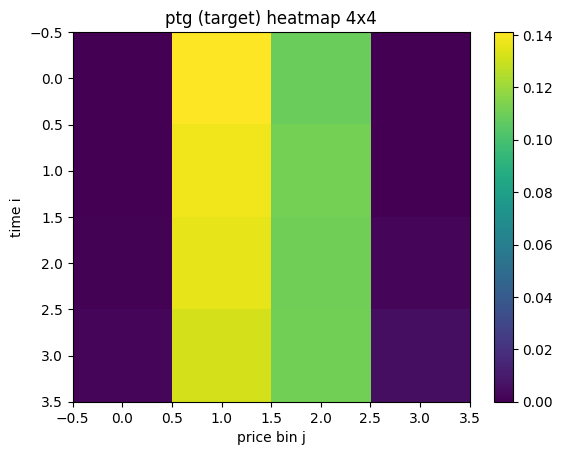

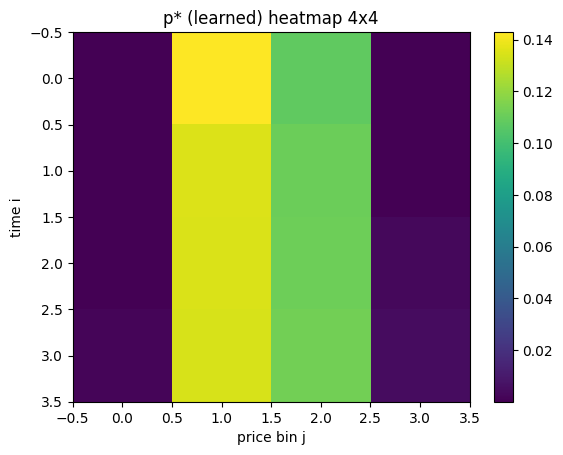

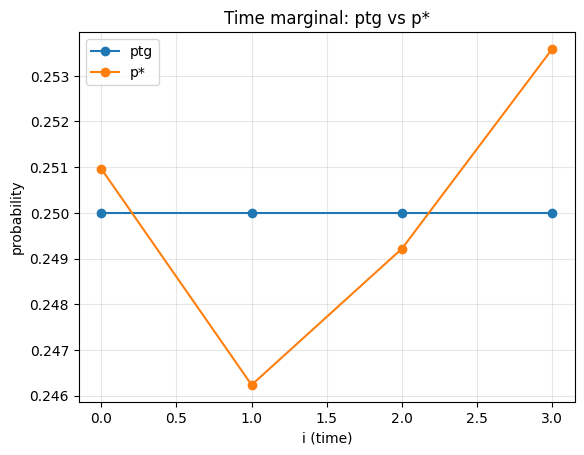

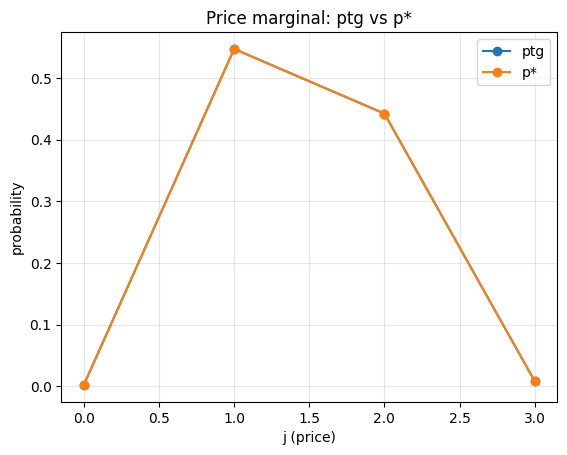

In [102]:
plot_joint_and_marginals(
    ptg=ptg,
    p_star=p_star,
    M=M,
    N=2**n,
    order="time_major",
    title_suffix="4x4",
)

#### 2. Estimation under the *shot-based* setting

In [14]:
# -----------------------------
# Settings (HIGH COMPUTE)
# -----------------------------
SEED = 123
N_ITERS = 7000
EPS_COST = 1e-12

SHOTS = 16384
N_AVG = 5

A0 = 0.60
C0 = 0.10
ALPHA = 0.55
GAMMA = 0.35
A_SHIFT = 20

ALLOWED_INCREASE = 0.02
LAST_AVG = 100

# -----------------------------
# Schedules
# -----------------------------
k = np.arange(1, N_ITERS + 1, dtype=float)
lr_schedule   = A0 / (k + A_SHIFT) ** ALPHA
pert_schedule = C0 / k ** GAMMA

# -----------------------------
# Objective (training, stochastic)
# -----------------------------
cost_single = qcbm.cost_fn(ptg, eps=EPS_COST, shots=SHOTS, seed=None)

def averaged_cost(x: np.ndarray) -> float:
    return float(np.mean([cost_single(x) for _ in range(N_AVG)]))

# -----------------------------
# Trace EXACT training points (fx)
# -----------------------------
theta_history: list[np.ndarray] = []
cost_history: list[float] = []

def callback(nfev, x, fx, step_size, accepted):
    theta_history.append(np.asarray(x, dtype=float).copy())
    cost_history.append(float(fx))  # EXACT value used by SPSA

# -----------------------------
# Optimize
# -----------------------------
rng = np.random.default_rng(SEED)
x0 = rng.standard_normal(len(theta)).astype(float)

opt = SPSA(
    maxiter=int(N_ITERS),
    learning_rate=lr_schedule,
    perturbation=pert_schedule,
    blocking=True,
    allowed_increase=float(ALLOWED_INCREASE),
    last_avg=int(LAST_AVG),
    callback=callback,
)

res = opt.minimize(fun=averaged_cost, x0=x0)
theta_star = np.asarray(res.x, dtype=float)

# finalize histories (defensive truncation)
theta_history = theta_history[:N_ITERS]
cost_history = np.asarray(cost_history[:N_ITERS], dtype=float)

print("TRAIN DONE")
print("nfev:", getattr(res, "nfev", None), "nit:", getattr(res, "nit", None))
print("final cost (reported):", float(res.fun))
print("final cost (training avg @ theta*):", float(averaged_cost(theta_star)))


TRAIN DONE
nfev: 21001 nit: 7000
final cost (reported): 2.1316446787611785
final cost (training avg @ theta*): 2.131677433456507


{'kl': 0.05730021869540331, 'l1': 0.03623536951351383, 'tv': 0.018117684756756916, 'linf': 0.0057988281249999885}


C:\Users\guilb\AppData\Local\Temp\ipykernel_16116\3513244528.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


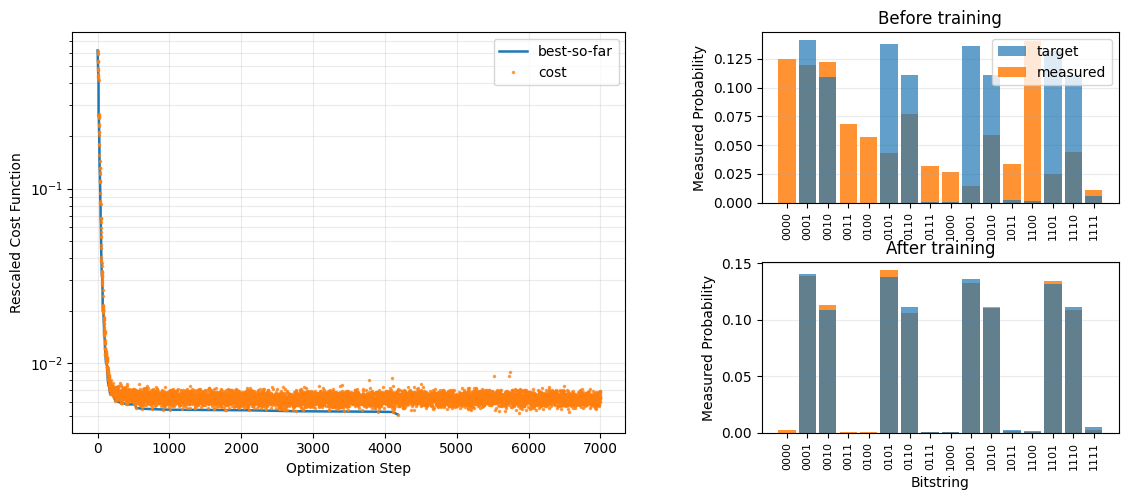

In [ ]:
# -----------------------------
# Histogram eval (does NOT affect training)
# -----------------------------
SEED_PLOT = 7
SHOTS_PLOT = 8192

p0 = qcbm.probabilities(x0, shots=SHOTS_PLOT, seed=SEED_PLOT)
p_star = qcbm.probabilities(theta_star, shots=SHOTS_PLOT, seed=SEED_PLOT)
metrics = qcbm.metrics(p_star, ptg)
# -----------------------------
# Cost function rescaling + best-so-far
# -----------------------------
C_star = -np.sum(ptg * np.log(np.maximum(ptg, EPS_COST)))
rescaled = cost_history - C_star
rescaled_plot = np.maximum(rescaled, 1e-12)
best_so_far = np.minimum.accumulate(rescaled_plot)

tol = 1e-15
best_idx = np.flatnonzero(np.r_[True, best_so_far[1:] < best_so_far[:-1] - tol])

# -----------------------------
# Plot
# -----------------------------
n_total = qcbm.n_qubits
bitstrings = [format(i, f"0{n_total}b") for i in range(2**n_total)]
xb = np.arange(len(bitstrings))
bar_w = 0.85

fig = plt.figure(figsize=(13.5, 5.2))
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.55, 1.0],
    height_ratios=[1, 1],
    wspace=0.30,
    hspace=0.35,
)

print(metrics)

ax_cost   = fig.add_subplot(gs[:, 0])
ax_top    = fig.add_subplot(gs[0, 1])
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_top)

ax_cost.semilogy(best_idx, best_so_far[best_idx], linewidth=1.8, label="best-so-far")
ax_cost.semilogy(rescaled_plot, linestyle="none", marker=".", markersize=3, alpha=0.7, label="cost")

ax_cost.set_xlabel("Optimization Step")
ax_cost.set_ylabel("Rescaled Cost Function")
ax_cost.grid(True, which="both", alpha=0.25)
ax_cost.legend(frameon=True)

ax_top.bar(xb, ptg, width=bar_w, alpha=0.70, label="target", zorder=2)
ax_top.bar(xb, p0,  width=bar_w, alpha=0.85, label="measured", zorder=1)
ax_top.set_title("Before training")
ax_top.set_ylabel("Measured Probability")
ax_top.set_xticks(xb)
ax_top.set_xticklabels(bitstrings, rotation=90, fontsize=8)
ax_top.grid(True, axis="y", alpha=0.25)
ax_top.legend(frameon=True)

ax_bottom.bar(xb, ptg,    width=bar_w, alpha=0.70, label="target", zorder=2)
ax_bottom.bar(xb, p_star, width=bar_w, alpha=0.85, label="measured", zorder=1)
ax_bottom.set_title("After training")
ax_bottom.set_ylabel("Measured Probability")
ax_bottom.set_xlabel("Bitstring")
ax_bottom.set_xticks(xb)
ax_bottom.set_xticklabels(bitstrings, rotation=90, fontsize=8)
ax_bottom.grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()
